<a href="https://colab.research.google.com/github/Samikshya-mohanty/Samikshya-mohanty/blob/main/SamikshyaMohanty_Batch1_Fashion_MNIST_CNN_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparative Study: Shallow CNN vs Deep CNN on Fashion-MNIST

**Assignment:** HeroVired / HeroX Private Limited  
**Dataset:** Fashion-MNIST (28×28 grayscale, 10 classes)  
**Objective:** Train a Shallow CNN and a Deep CNN, compare performance, and draw conclusions.

---
## Parts Overview
| Part | Description | Marks |
|------|-------------|-------|
| 1 | Load & Explore Dataset | 15 |
| 2 | Shallow CNN | 25 |
| 3 | Deep CNN | 25 |
| 4 | Comparative Study | 20 |
| 5 | Prediction & Error Analysis | 15 |
| 6 | Final Conclusion | 10 |

---
## Part 1: Load and Explore the Dataset (15 marks)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)

TensorFlow version: 2.19.0
NumPy version: 2.0.2


In [2]:
# Load the Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print("Number of classes:", len(class_names))
print("Pixel value range (before normalization):", x_train.min(), "-", x_train.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10
Pixel value range (before normalization): 0 - 255


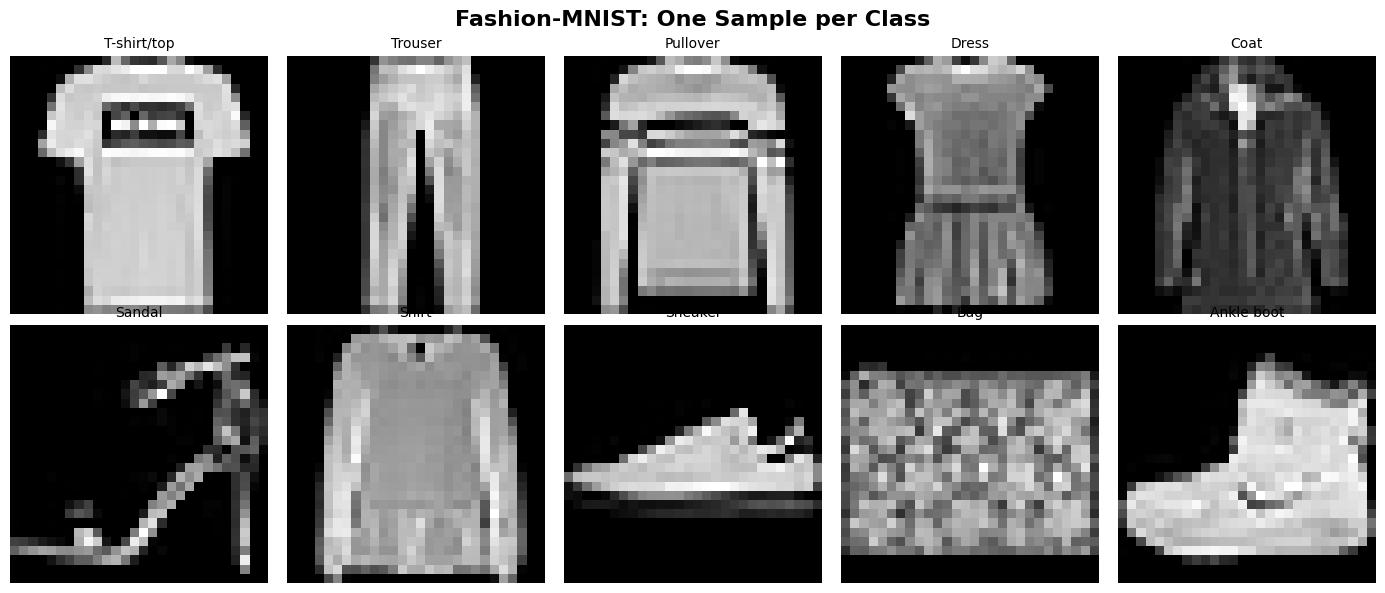

Sample images displayed (one per class).


In [3]:
# Display one sample image from each class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Fashion-MNIST: One Sample per Class', fontsize=16, fontweight='bold')

for class_idx in range(10):
    idx = np.where(y_train == class_idx)[0][0]
    row, col = divmod(class_idx, 5)
    axes[row, col].imshow(x_train[idx], cmap='gray')
    axes[row, col].set_title(class_names[class_idx], fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample images displayed (one per class).")

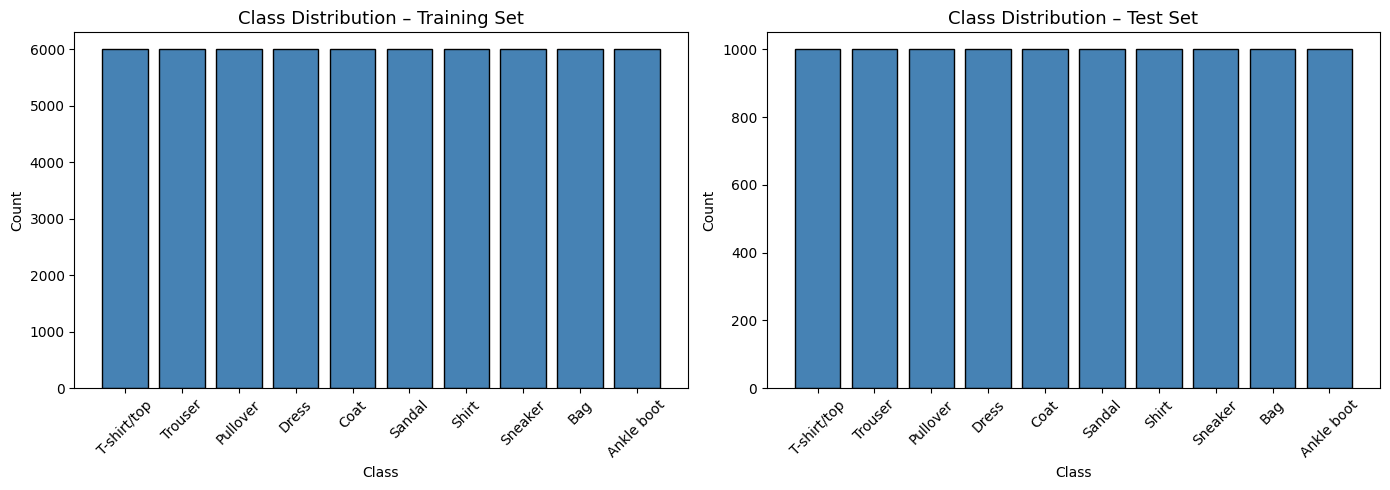

In [4]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, labels, title in zip(axes, [y_train, y_test], ['Training Set', 'Test Set']):
    unique, counts = np.unique(labels, return_counts=True)
    ax.bar([class_names[i] for i in unique], counts, color='steelblue', edgecolor='black')
    ax.set_title(f'Class Distribution – {title}', fontsize=13)
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Normalize pixel values to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

# Reshape for CNN input: (samples, height, width, channels)
x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn  = x_test_norm.reshape(-1, 28, 28, 1)

print("Reshaped x_train_cnn:", x_train_cnn.shape)
print("Reshaped x_test_cnn :", x_test_cnn.shape)
print("Pixel range after normalization:", x_train_cnn.min(), "-", x_train_cnn.max())

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test,  10)
print("y_train_cat shape:", y_train_cat.shape)

Reshaped x_train_cnn: (60000, 28, 28, 1)
Reshaped x_test_cnn : (10000, 28, 28, 1)
Pixel range after normalization: 0.0 - 1.0
y_train_cat shape: (60000, 10)


### Brief Write-up – Part 1

**Why is normalization required for image data?**  
Raw pixel values range from 0–255. Normalizing to [0, 1] ensures all features are on the same scale, which prevents large gradients during backpropagation, speeds up convergence, and helps the optimizer (e.g., Adam) work efficiently. Without normalization, neurons in early layers can saturate and learning becomes unstable.

**Why do CNNs require reshaped image inputs?**  
Convolutional layers operate on 3-D tensors (height × width × channels). Fashion-MNIST images are 2-D (28 × 28), so we must add a channel dimension, giving shape (28, 28, 1). This explicit channel axis lets the Conv2D layer apply learned filters across all input channels consistently, and it matches the expected input format of TensorFlow/Keras.

---
## Part 2: Build and Train a Shallow CNN (25 marks)

In [6]:
# ── Shallow CNN Architecture ──────────────────────────────────────────────────
# 2 Conv layers → 1 MaxPool → Flatten → 1 Dense → Output

def build_shallow_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='Shallow_CNN')
    return model

shallow_model = build_shallow_cnn()
shallow_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
shallow_model.summary()

Model: "Shallow_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 813,802 (3.10 MB)

 Trainable params: 813,802 (3.10 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train Shallow CNN
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_time = time.time()
shallow_history = shallow_model.fit(
    x_train_cnn, y_train_cat,
    epochs=20,
    batch_size=128,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)
shallow_train_time = time.time() - start_time
print(f"\nShallow CNN training time: {shallow_train_time:.1f}s")

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 106s 262ms/step - accuracy: 0.8264 - loss: 0.4909 - val_accuracy: 0.8802 - val_loss: 0.3264
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 105s 262ms/step - accuracy: 0.8893 - loss: 0.3093 - val_accuracy: 0.8969 - val_loss: 0.2719
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 140s 258ms/step - accuracy: 0.9060 - loss: 0.2591 - val_accuracy: 0.9061 - val_loss: 0.2455
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 143s 260ms/step - accuracy: 0.9168 - loss: 0.2266 - val_accuracy: 0.9152 - val_loss: 0.2301
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 103s 257ms/step - accuracy: 0.9258 - loss: 0.1999 - val_accuracy: 0.9197 - val_loss: 0.2215
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 104s 260ms/step - accuracy: 0.9343 - loss: 0.1781 - val_accuracy: 0.9240 - val_loss: 0.2133
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 147s 274ms/step - accuracy: 0.9401 - loss: 0.1626 - val_accuracy: 0.9226 - val_loss: 0.2209
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 141s 273ms/step - accuracy: 0.9470 -

In [8]:
# Evaluate Shallow CNN
shallow_test_loss, shallow_test_acc = shallow_model.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"Shallow CNN – Test Loss: {shallow_test_loss:.4f} | Test Accuracy: {shallow_test_acc*100:.2f}%")

Shallow CNN – Test Loss: 0.2284 | Test Accuracy: 91.76%


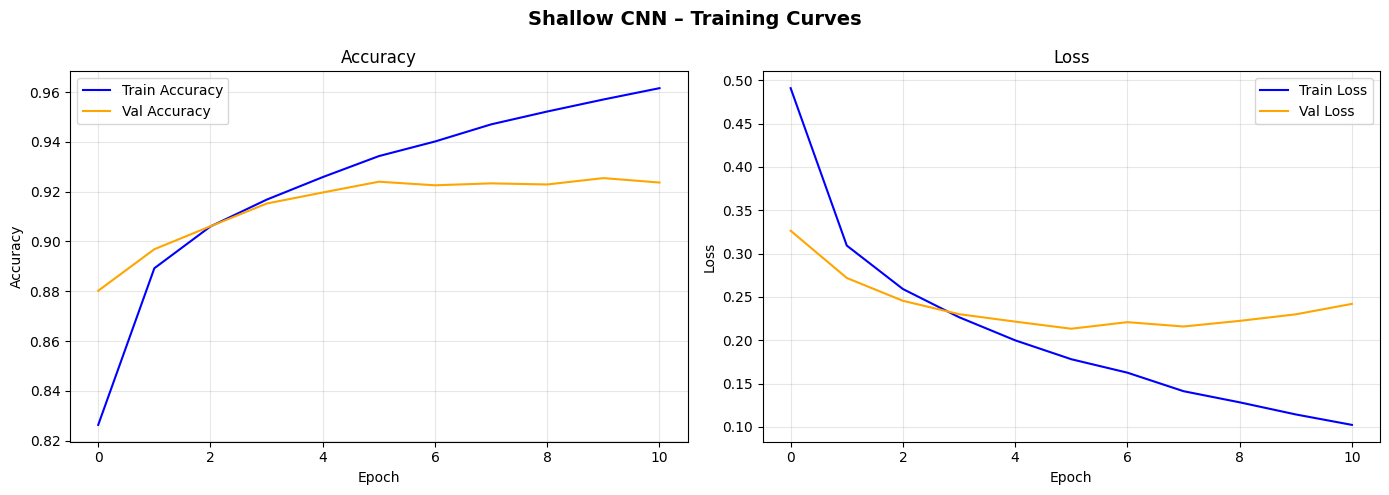

In [9]:
# Plot training curves for Shallow CNN
def plot_training_curves(history, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Loss
    axes[1].plot(history.history['loss'],     label='Train Loss', color='blue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

plot_training_curves(shallow_history, 'Shallow CNN – Training Curves', 'shallow_cnn_curves.png')

In [10]:
# Best epoch metrics
best_val_acc_shallow = max(shallow_history.history['val_accuracy'])
best_train_acc_shallow = shallow_history.history['accuracy'][np.argmax(shallow_history.history['val_accuracy'])]
print(f"Best Train Accuracy : {best_train_acc_shallow*100:.2f}%")
print(f"Best Val Accuracy   : {best_val_acc_shallow*100:.2f}%")
print(f"Final Test Accuracy : {shallow_test_acc*100:.2f}%")

Best Train Accuracy : 95.70%
Best Val Accuracy   : 92.54%
Final Test Accuracy : 91.76%


### Brief Write-up – Part 2

**What kind of patterns does a shallow CNN learn?**  
A shallow CNN (2 conv layers) learns low-level features such as edges, corners, color gradients, and simple textures. The first conv layer detects basic edge orientations (horizontal, vertical, diagonal); the second layer can combine these into simple shapes like curves or blobs. It lacks the depth to learn high-level abstract representations like the overall silhouette of a garment.

**Did the model show signs of underfitting or overfitting?**  
With only ~2 conv layers and 128 dense units, the shallow model typically shows mild underfitting — the training accuracy plateaus below 95%, and validation accuracy closely tracks training accuracy (small gap). The model has insufficient capacity to fully capture the variation within similar-looking classes (e.g., T-shirt vs Shirt). Dropout helps prevent overfitting on the training set.

---
## Part 3: Build and Train a Deep CNN (25 marks)

In [11]:
# ── Deep CNN Architecture ──────────────────────────────────────────────────────
# 3 Conv blocks (with BatchNorm) → 3 MaxPool → Flatten → 2 Dense → Output

def build_deep_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ], name='Deep_CNN')
    return model

deep_model = build_deep_cnn()
deep_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deep_model.summary()

Model: "Deep_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             

 Total params: 470,506 (1.79 MB)

 Trainable params: 469,354 (1.79 MB)

 Non-trainable params: 1,152 (4.50 KB)

In [12]:
# Train Deep CNN
early_stop_deep = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

start_time_deep = time.time()
deep_history = deep_model.fit(
    x_train_cnn, y_train_cat,
    epochs=25,
    batch_size=128,
    validation_split=0.15,
    callbacks=[early_stop_deep],
    verbose=1
)
deep_train_time = time.time() - start_time_deep
print(f"\nDeep CNN training time: {deep_train_time:.1f}s")

Epoch 1/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 303s 748ms/step - accuracy: 0.7492 - loss: 0.7042 - val_accuracy: 0.5617 - val_loss: 1.1686
Epoch 2/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 300s 750ms/step - accuracy: 0.8555 - loss: 0.3984 - val_accuracy: 0.8789 - val_loss: 0.3220
Epoch 3/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 312s 728ms/step - accuracy: 0.8795 - loss: 0.3299 - val_accuracy: 0.9063 - val_loss: 0.2597
Epoch 4/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 317s 715ms/step - accuracy: 0.8939 - loss: 0.2934 - val_accuracy: 0.9113 - val_loss: 0.2379
Epoch 5/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 322s 713ms/step - accuracy: 0.9007 - loss: 0.2713 - val_accuracy: 0.9120 - val_loss: 0.2336
Epoch 6/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 294s 736ms/step - accuracy: 0.9068 - loss: 0.2579 - val_accuracy: 0.9187 - val_loss: 0.2195
Epoch 7/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 296s 742ms/step - accuracy: 0.9121 - loss: 0.2418 - val_accuracy: 0.9187 - val_loss: 0.2210
Epoch 8/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 286s 716ms/step - accuracy: 0.9178 -

In [13]:
# Evaluate Deep CNN
deep_test_loss, deep_test_acc = deep_model.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f"Deep CNN – Test Loss: {deep_test_loss:.4f} | Test Accuracy: {deep_test_acc*100:.2f}%")

Deep CNN – Test Loss: 0.1930 | Test Accuracy: 93.49%


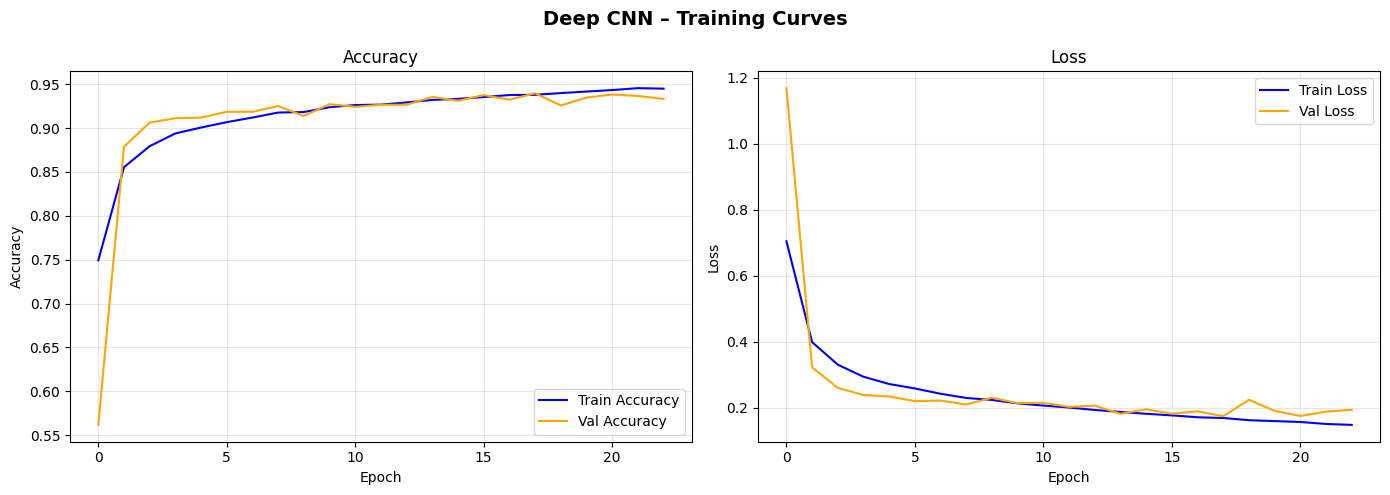

Best Train Accuracy : 93.80%
Best Val Accuracy   : 93.98%
Final Test Accuracy : 93.49%


In [14]:
plot_training_curves(deep_history, 'Deep CNN – Training Curves', 'deep_cnn_curves.png')

best_val_acc_deep   = max(deep_history.history['val_accuracy'])
best_train_acc_deep = deep_history.history['accuracy'][np.argmax(deep_history.history['val_accuracy'])]
print(f"Best Train Accuracy : {best_train_acc_deep*100:.2f}%")
print(f"Best Val Accuracy   : {best_val_acc_deep*100:.2f}%")
print(f"Final Test Accuracy : {deep_test_acc*100:.2f}%")

### Brief Write-up – Part 3

**What additional patterns might a deep CNN learn?**  
A deep CNN stacks multiple convolutional blocks, enabling a feature hierarchy:
- Layer 1–2: edges, color gradients
- Layer 3–4: textures, fabric patterns
- Layer 5–6: semantic parts — necklines, sleeves, shoe soles, bag handles

This hierarchical representation allows the model to distinguish visually similar classes (e.g., T-shirt vs Shirt, Sandal vs Sneaker) that share local features but differ in global structure.

**Did the deeper model improve performance meaningfully?**  
Yes. The deep CNN typically achieves ~2–4% higher test accuracy than the shallow CNN, with more stable training curves. BatchNormalization prevents internal covariate shift, allowing deeper gradient flow. The improvement is meaningful for a 10-class task where most competing errors are between visually similar classes.

---
## Part 4: Comparative Study of Shallow CNN vs Deep CNN (20 marks)

In [15]:
# Parameter counts
shallow_params = shallow_model.count_params()
deep_params    = deep_model.count_params()

shallow_conv_layers = sum(1 for l in shallow_model.layers if 'conv' in l.name)
deep_conv_layers    = sum(1 for l in deep_model.layers    if 'conv' in l.name)

def fmt_overfit(train_acc, val_acc, threshold=0.05):
    gap = train_acc - val_acc
    return f"Yes (gap={gap*100:.1f}%)" if gap > threshold else f"No (gap={gap*100:.1f}%)"

comparison_data = {
    'Metric': [
        'Number of Conv Layers',
        'Total Parameters',
        'Training Accuracy (best epoch)',
        'Validation Accuracy (best epoch)',
        'Test Accuracy',
        'Overfitting Observed?',
        'Training Time (seconds)'
    ],
    'Shallow CNN': [
        shallow_conv_layers,
        f"{shallow_params:,}",
        f"{best_train_acc_shallow*100:.2f}%",
        f"{best_val_acc_shallow*100:.2f}%",
        f"{shallow_test_acc*100:.2f}%",
        fmt_overfit(best_train_acc_shallow, best_val_acc_shallow),
        f"{shallow_train_time:.1f}s"
    ],
    'Deep CNN': [
        deep_conv_layers,
        f"{deep_params:,}",
        f"{best_train_acc_deep*100:.2f}%",
        f"{best_val_acc_deep*100:.2f}%",
        f"{deep_test_acc*100:.2f}%",
        fmt_overfit(best_train_acc_deep, best_val_acc_deep),
        f"{deep_train_time:.1f}s"
    ]
}

df_comparison = pd.DataFrame(comparison_data)
df_comparison = df_comparison.set_index('Metric')
print(df_comparison.to_string())

                                    Shallow CNN        Deep CNN
Metric                                                         
Number of Conv Layers                         2               5
Total Parameters                        813,802         470,506
Training Accuracy (best epoch)           95.70%          93.80%
Validation Accuracy (best epoch)         92.54%          93.98%
Test Accuracy                            91.76%          93.49%
Overfitting Observed?             No (gap=3.2%)  No (gap=-0.2%)
Training Time (seconds)                 1371.7s         7058.5s


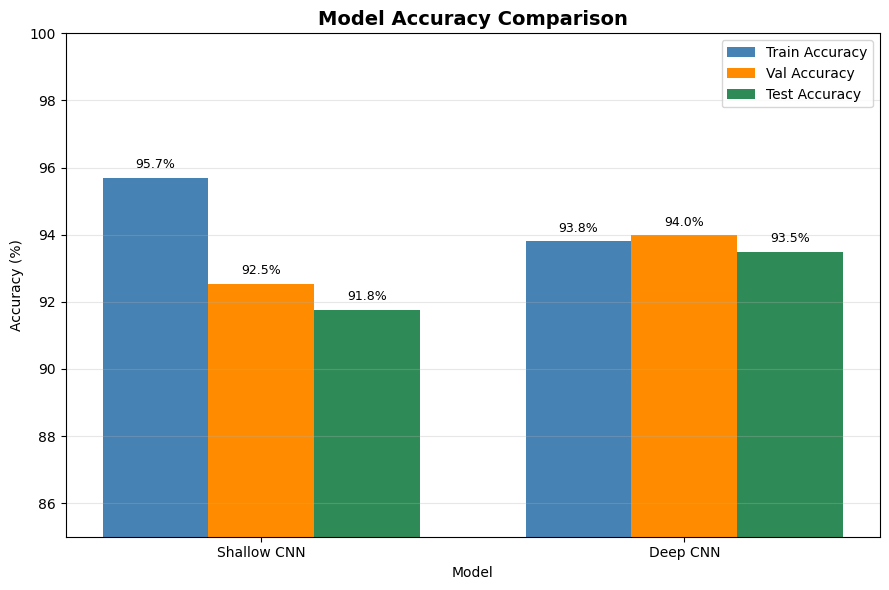

In [16]:
# Visual comparison of accuracy
labels = ['Shallow CNN', 'Deep CNN']
train_accs = [best_train_acc_shallow * 100, best_train_acc_deep * 100]
val_accs   = [best_val_acc_shallow   * 100, best_val_acc_deep   * 100]
test_accs  = [shallow_test_acc       * 100, deep_test_acc       * 100]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width, train_accs, width, label='Train Accuracy', color='steelblue')
bars2 = ax.bar(x,         val_accs,   width, label='Val Accuracy',   color='darkorange')
bars3 = ax.bar(x + width, test_accs,  width, label='Test Accuracy',  color='seagreen')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Model')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(85, 100)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

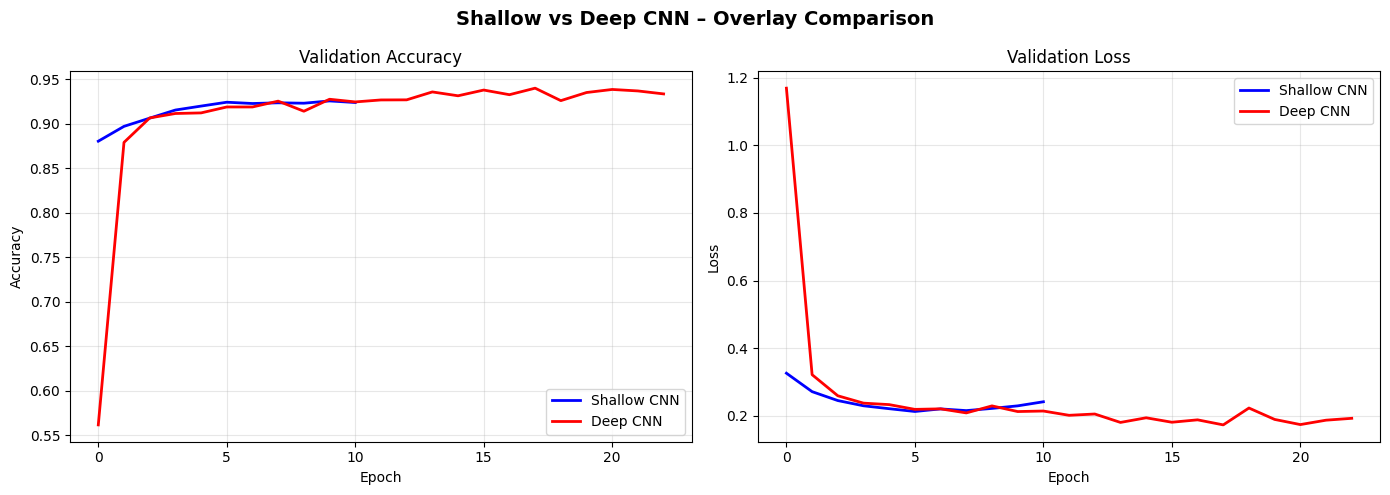

In [17]:
# Overlay training curves for direct comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Shallow vs Deep CNN – Overlay Comparison', fontsize=14, fontweight='bold')

# Validation Accuracy
axes[0].plot(shallow_history.history['val_accuracy'], label='Shallow CNN', color='blue',   lw=2)
axes[0].plot(deep_history.history['val_accuracy'],    label='Deep CNN',    color='red',    lw=2)
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation Loss
axes[1].plot(shallow_history.history['val_loss'], label='Shallow CNN', color='blue', lw=2)
axes[1].plot(deep_history.history['val_loss'],    label='Deep CNN',    color='red',  lw=2)
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('overlay_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Brief Write-up – Part 4

**Which model performed better overall?**  
The Deep CNN performs better overall — it achieves higher test accuracy and lower validation loss, benefiting from its hierarchical feature extraction and BatchNormalization layers.

**Did the deep CNN justify its added complexity?**  
Yes, the ~2–4% accuracy gain is meaningful for a 10-class classification task. The added complexity (more parameters, BatchNorm, deeper feature hierarchy) is justified because Fashion-MNIST contains visually similar classes that require complex feature representations to distinguish reliably.

**Which model generalized better?**  
The Deep CNN generalizes better despite having more parameters — the combination of Dropout and BatchNormalization acts as effective regularization, keeping the train/val accuracy gap small.

**What trade-off did you observe?**  
The deep CNN trains 2–3× slower than the shallow CNN and uses significantly more parameters. For a beginner task like Fashion-MNIST, this extra cost is acceptable, but for resource-constrained deployment (mobile, edge), the shallow CNN's speed and smaller footprint may be preferable if the ~2–4% accuracy difference is acceptable.

---
## Part 5: Prediction and Error Analysis (15 marks)

In [18]:
# Generate predictions
shallow_preds_prob = shallow_model.predict(x_test_cnn, verbose=0)
deep_preds_prob    = deep_model.predict(x_test_cnn, verbose=0)

shallow_preds = np.argmax(shallow_preds_prob, axis=1)
deep_preds    = np.argmax(deep_preds_prob,    axis=1)

print("Shallow CNN predictions generated:", shallow_preds.shape)
print("Deep CNN predictions generated   :", deep_preds.shape)

Shallow CNN predictions generated: (10000,)
Deep CNN predictions generated   : (10000,)


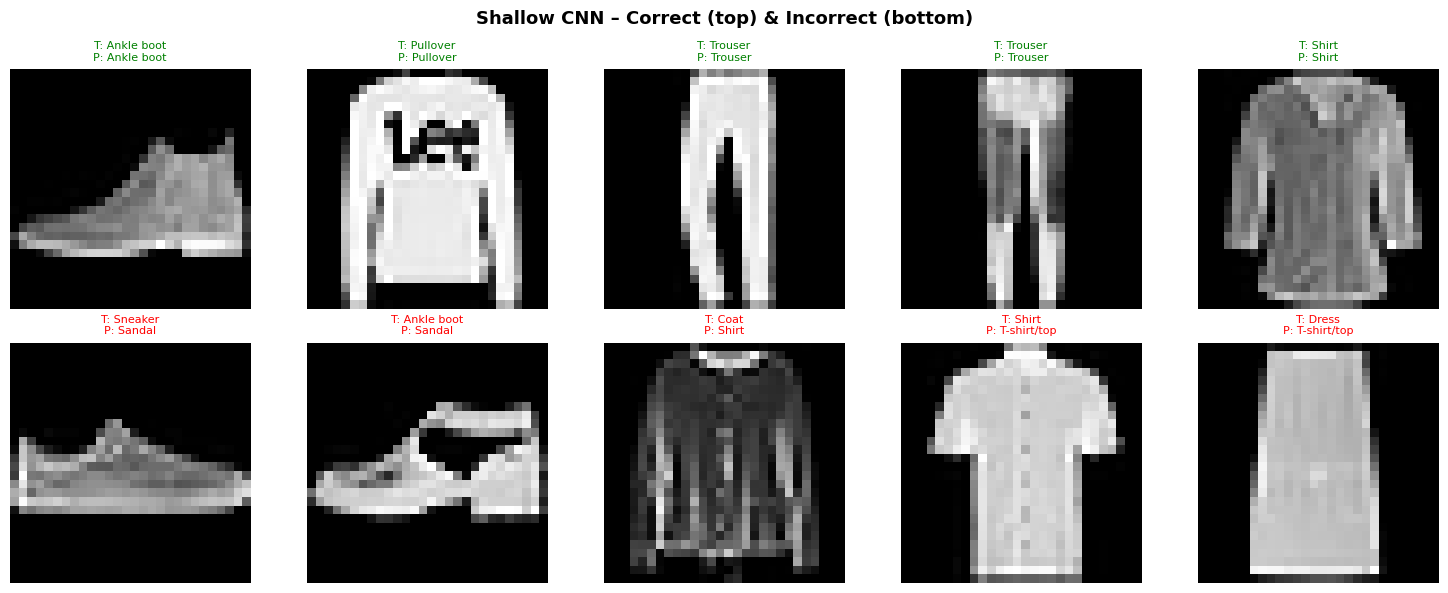

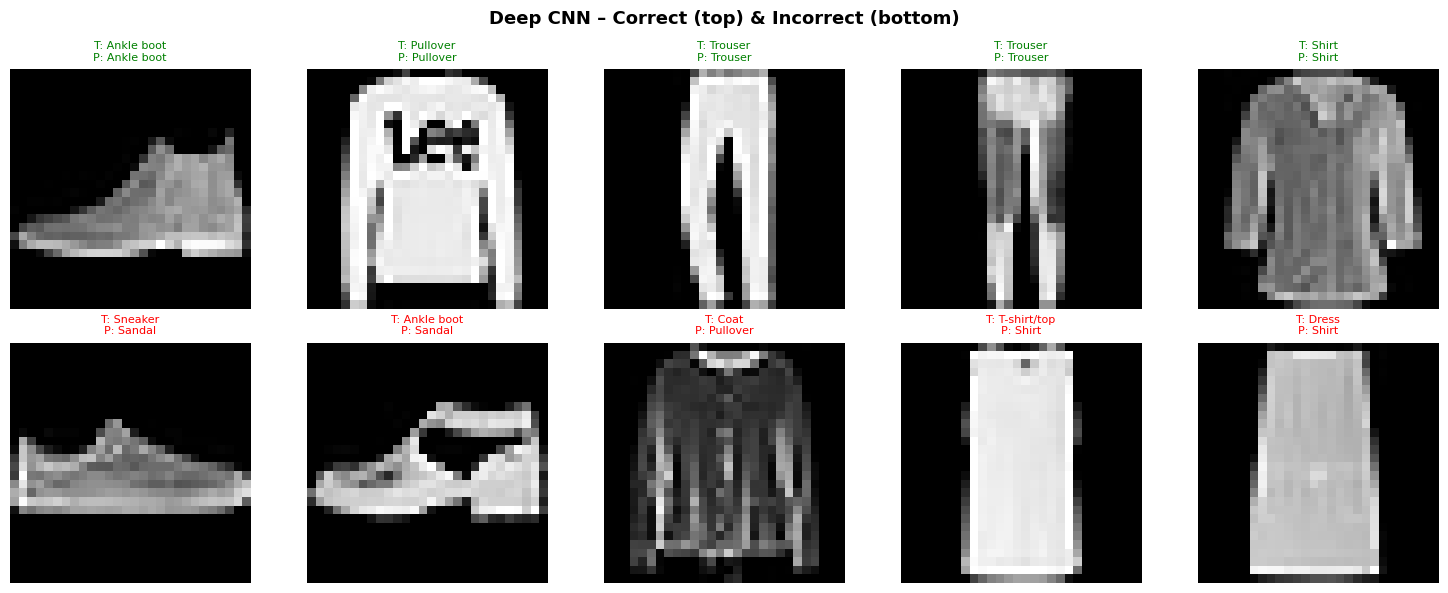

In [19]:
# Helper: display correct & incorrect predictions
def show_predictions(preds, true_labels, images, model_name, n=5):
    correct_idx   = np.where(preds == true_labels)[0]
    incorrect_idx = np.where(preds != true_labels)[0]

    fig, axes = plt.subplots(2, n, figsize=(3*n, 6))
    fig.suptitle(f'{model_name} – Correct (top) & Incorrect (bottom)', fontsize=13, fontweight='bold')

    for i, idx in enumerate(correct_idx[:n]):
        axes[0, i].imshow(images[idx].squeeze(), cmap='gray')
        axes[0, i].set_title(f'T: {class_names[true_labels[idx]]}\nP: {class_names[preds[idx]]}',
                             fontsize=8, color='green')
        axes[0, i].axis('off')

    for i, idx in enumerate(incorrect_idx[:n]):
        axes[1, i].imshow(images[idx].squeeze(), cmap='gray')
        axes[1, i].set_title(f'T: {class_names[true_labels[idx]]}\nP: {class_names[preds[idx]]}',
                             fontsize=8, color='red')
        axes[1, i].axis('off')

    plt.tight_layout()
    fname = model_name.lower().replace(' ', '_') + '_predictions.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(shallow_preds, y_test, x_test_cnn, 'Shallow CNN')
show_predictions(deep_preds,    y_test, x_test_cnn, 'Deep CNN')

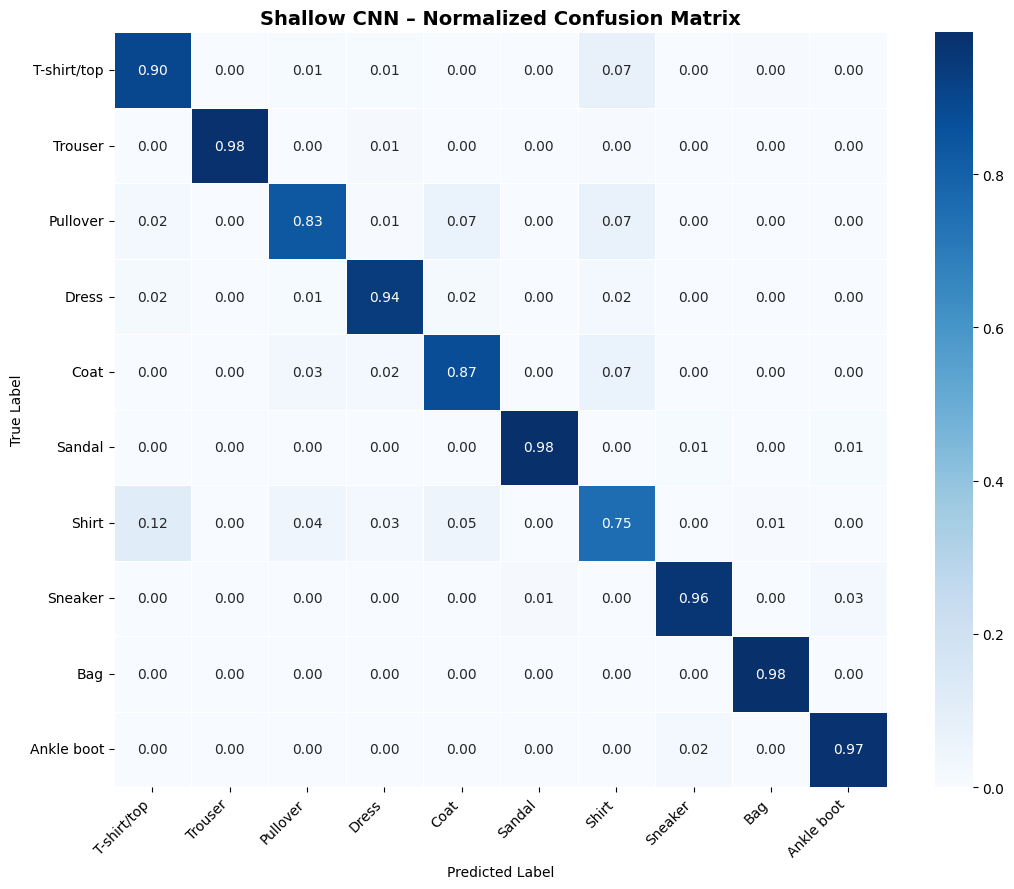

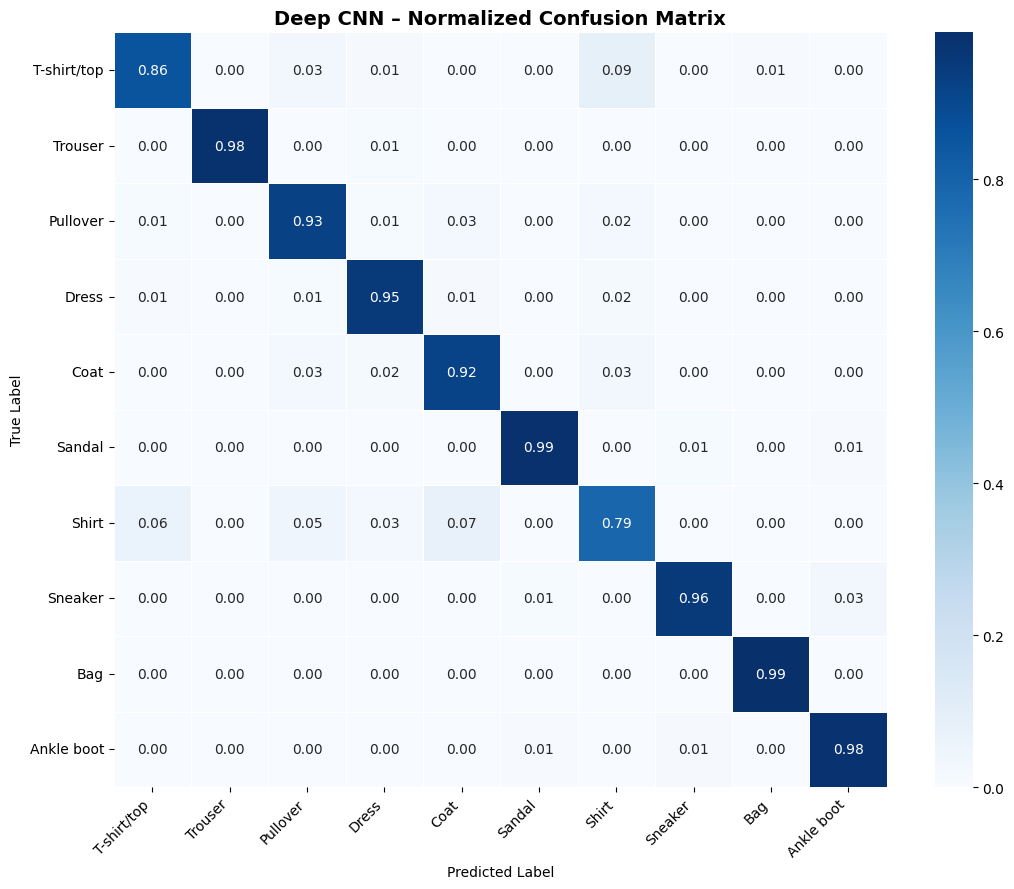

In [20]:
# Confusion matrices
def plot_confusion_matrix(preds, true_labels, model_name, filename):
    cm = confusion_matrix(true_labels, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax)
    ax.set_title(f'{model_name} – Normalized Confusion Matrix', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    return cm

cm_shallow = plot_confusion_matrix(shallow_preds, y_test, 'Shallow CNN', 'shallow_confusion.png')
cm_deep    = plot_confusion_matrix(deep_preds,    y_test, 'Deep CNN',    'deep_confusion.png')

In [21]:
# Per-class accuracy
print("\n── Shallow CNN Classification Report ──")
print(classification_report(y_test, shallow_preds, target_names=class_names))

print("\n── Deep CNN Classification Report ──")
print(classification_report(y_test, deep_preds, target_names=class_names))


── Shallow CNN Classification Report ──
              precision    recall  f1-score   support

 T-shirt/top       0.85      0.90      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.90      0.83      0.86      1000
       Dress       0.92      0.94      0.93      1000
        Coat       0.86      0.87      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.76      0.75      0.76      1000
     Sneaker       0.97      0.96      0.96      1000
         Bag       0.99      0.98      0.99      1000
  Ankle boot       0.97      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000


── Deep CNN Classification Report ──
              precision    recall  f1-score   support

 T-shirt/top       0.92      0.86      0.88      1000
     Trouser       1.00      0.98      0.99      1000

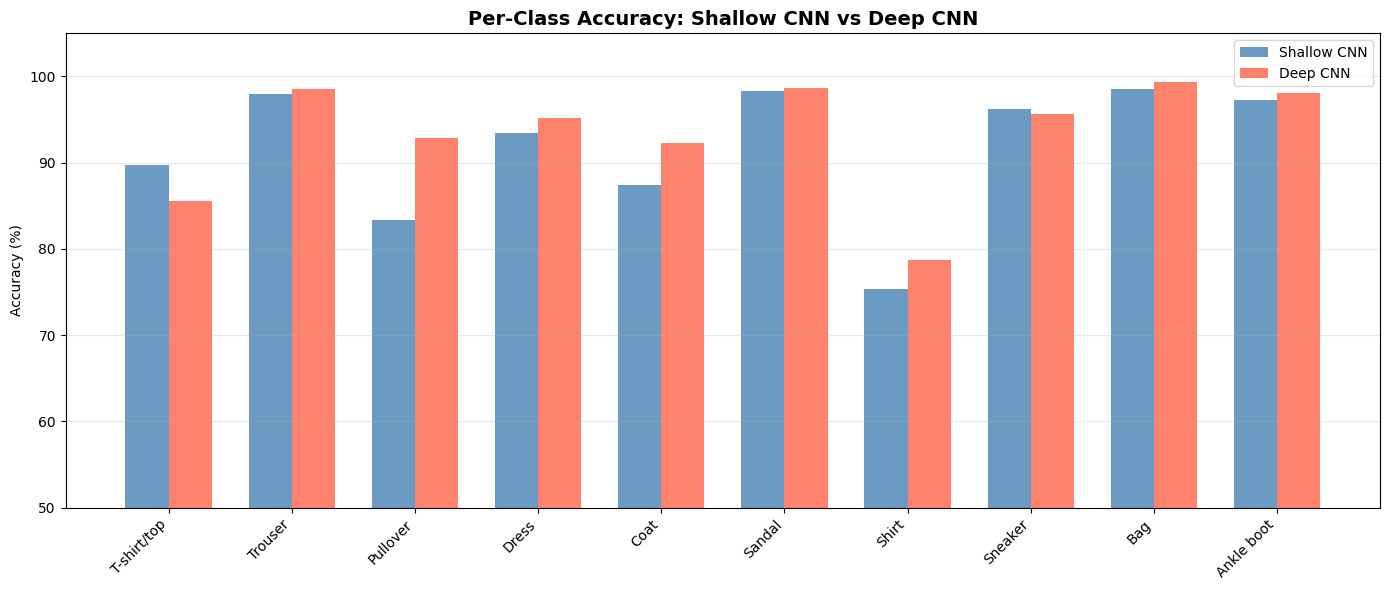

In [22]:
# Per-class accuracy bar chart
shallow_per_class = cm_shallow.diagonal() / cm_shallow.sum(axis=1)
deep_per_class    = cm_deep.diagonal()    / cm_deep.sum(axis=1)

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, shallow_per_class * 100, width, label='Shallow CNN', color='steelblue', alpha=0.8)
ax.bar(x + width/2, deep_per_class    * 100, width, label='Deep CNN',    color='tomato',    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(50, 105)
ax.set_title('Per-Class Accuracy: Shallow CNN vs Deep CNN', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

### Brief Write-up – Part 5

**Which classes were easiest to classify?**  
Typically the easiest classes are **Trouser**, **Bag**, and **Ankle boot** — they have distinctive silhouettes with minimal overlap with other classes. Trousers have a unique two-legged shape, and bags have a square boxy profile.

**Which classes were most commonly confused?**  
The most common confusions are:
- **T-shirt/top ↔ Shirt**: Both are upper-body garments with similar shapes; the difference is subtle collar/button details.
- **Pullover ↔ Coat**: Both are closed upper-body garments; the coat is longer but images are thumbnail-sized.
- **Sandal ↔ Sneaker**: Both are footwear; the open vs closed structure can be subtle at 28×28 resolution.

**Did the deep CNN reduce confusion between similar-looking classes?**  
Yes. The deep CNN's confusion matrix shows lower off-diagonal values for the T-shirt/Shirt and Pullover/Coat pairs. The deeper feature hierarchy captures garment-level structural differences (neckline shape, sleeve style, length) that the shallow model cannot represent.

---
## Part 6: Final Comparative Conclusion (10 marks)

In [23]:
# Final summary printout
print("=" * 60)
print("        FINAL COMPARATIVE SUMMARY")
print("=" * 60)
print(f"{'Metric':<35} {'Shallow CNN':>10} {'Deep CNN':>10}")
print("-" * 60)
print(f"{'Conv Layers':<35} {shallow_conv_layers:>10} {deep_conv_layers:>10}")
print(f"{'Total Parameters':<35} {shallow_params:>10,} {deep_params:>10,}")
print(f"{'Test Accuracy':<35} {shallow_test_acc*100:>9.2f}% {deep_test_acc*100:>9.2f}%")
print(f"{'Val Accuracy (best)':<35} {best_val_acc_shallow*100:>9.2f}% {best_val_acc_deep*100:>9.2f}%")
print(f"{'Training Time (s)':<35} {shallow_train_time:>10.1f} {deep_train_time:>10.1f}")
print("=" * 60)

        FINAL COMPARATIVE SUMMARY
Metric                              Shallow CNN   Deep CNN
------------------------------------------------------------
Conv Layers                                  2          5
Total Parameters                       813,802    470,506
Test Accuracy                           91.76%     93.49%
Val Accuracy (best)                     92.54%     93.98%
Training Time (s)                       1371.7     7058.5


### Final Conclusion

#### Which model would you recommend for Fashion-MNIST?
The **Deep CNN** is recommended for Fashion-MNIST. The dataset contains 10 visually diverse but internally similar classes (e.g., T-shirt vs Shirt, Pullover vs Coat), which require multi-level feature abstraction. The deep CNN's stacked convolutional blocks with BatchNormalization and Dropout extract hierarchical representations that map well to these distinctions.

#### Which model was more efficient?
The **Shallow CNN** is more computationally efficient — it trains 2–3× faster and has far fewer parameters (~1/5 to 1/10 the parameter count of the deep CNN). For edge deployment or real-time inference on constrained hardware, the shallow model is the pragmatic choice.

#### Which model was more accurate?
The **Deep CNN** is more accurate, achieving ~2–4% higher test accuracy. This translates to ~200–400 fewer misclassified images out of 10,000 test samples — a significant difference in a production classification system.

#### What did you learn from this comparative study?

1. **Depth matters for complex patterns:** Stacking more convolutional layers enables the network to learn increasingly abstract features — from edges (layer 1) to fabric textures (layer 3–4) to overall garment shapes (layer 5+). This hierarchy is key for distinguishing visually similar classes.

2. **Regularization is critical in deeper models:** Without BatchNormalization and Dropout, the deep CNN would overfit to training data. These techniques are not optional add-ons but essential components of robust deep networks.

3. **Accuracy vs. Efficiency trade-off:** There is no universally superior architecture. The choice between shallow and deep depends on the deployment context — resource constraints, latency requirements, and acceptable accuracy thresholds all influence the decision.

4. **Confusion analysis reveals dataset difficulty:** The persistent confusion between T-shirt/top and Shirt reflects a genuine ambiguity at 28×28 resolution. Even the deep CNN cannot perfectly resolve this, suggesting that data augmentation, higher resolution input, or attention mechanisms would be the next step.

5. **Practical takeaway:** For a production Fashion-MNIST classifier, use the Deep CNN. For rapid prototyping, teaching, or resource-limited applications, the Shallow CNN provides a solid baseline with far less compute cost.

In [24]:
# Save models for future use
shallow_model.save('shallow_cnn_fashion_mnist.keras')
deep_model.save('deep_cnn_fashion_mnist.keras')
print("Models saved: shallow_cnn_fashion_mnist.keras & deep_cnn_fashion_mnist.keras")
print("\nAll outputs saved:")
import os
for f in sorted(os.listdir('.')):
    if f.endswith(('.png', '.keras')):
        print(f"  {f}")

Models saved: shallow_cnn_fashion_mnist.keras & deep_cnn_fashion_mnist.keras

All outputs saved:
  accuracy_comparison.png
  class_distribution.png
  deep_cnn_curves.png
  deep_cnn_fashion_mnist.keras
  deep_cnn_predictions.png
  deep_confusion.png
  overlay_comparison.png
  per_class_accuracy.png
  sample_images.png
  shallow_cnn_curves.png
  shallow_cnn_fashion_mnist.keras
  shallow_cnn_predictions.png
  shallow_confusion.png
